In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Dataset

In [42]:
df = pd.read_csv('loan_approval_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [43]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Data Preprocessing

In [44]:
categ_cols = df.select_dtypes(include=['object']).columns
numer_cols = df.select_dtypes(include=['number']).columns

# this separate out the columns on the basis of datatype

In [45]:
from sklearn.impute import SimpleImputer
# this library is for filling the missing values by particular method

num_imp = SimpleImputer(strategy='mean')
df[numer_cols] = num_imp.fit_transform(df[numer_cols])

cat_imp = SimpleImputer(strategy='most_frequent')
df[categ_cols] = cat_imp.fit_transform(df[categ_cols])

In [46]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [47]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

([<matplotlib.patches.Wedge at 0x1f58f49f390>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'Yes'),
  Text(0.6521428261765839, -0.8858384357581341, 'No')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

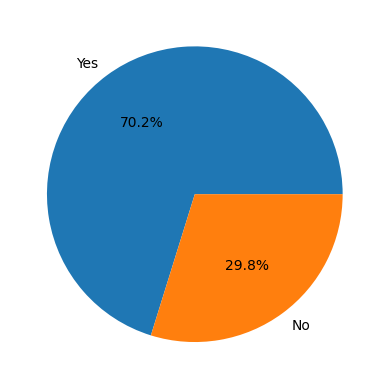

In [48]:
# Checks the percentage of the Target value

cnt = df['Loan_Approved'].value_counts()
plt.pie(cnt,labels=['Yes','No'], autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1f58f4e7d90>,
 [Text(-0.40814808922615514, 1.0214769391724117, 'Male'),
  Text(0.4081485438350891, -1.0214767575257386, 'Female')],
 [Text(-0.22262623048699368, 0.5571692395485881, '62.1%'),
  Text(0.22262647845550312, -0.5571691404685846, '37.9%')])

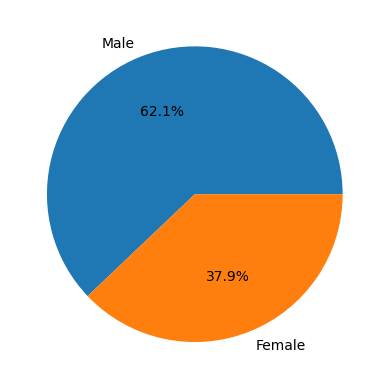

In [49]:
# Analyze categories

gender_cnt = df['Gender'].value_counts()
plt.pie(gender_cnt,labels=['Male','Female'], autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1f58f5507d0>,
 [Text(-0.706477973722957, 0.8431422612135542, 'Graduate'),
  Text(0.7064782484535398, -0.8431420310137662, 'Not Graduate')],
 [Text(-0.3853516220307037, 0.45989577884375676, '72.2%'),
  Text(0.3853517718837489, -0.459895653280236, '27.8%')])

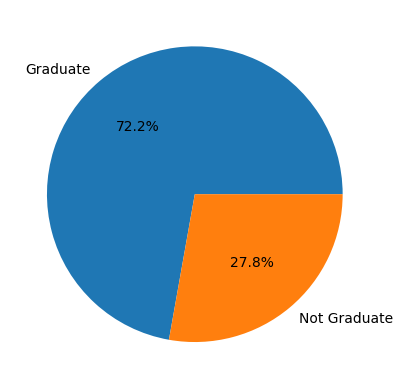

In [50]:
gender_cnt = df['Education_Level'].value_counts()
plt.pie(gender_cnt,labels=['Graduate','Not Graduate'], autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x1f58f420410>,
 [Text(-0.05872003539603588, 1.0984315897874972, 'Urban'),
  Text(-0.5658833236724473, -0.9432794198907472, 'SemiUrban'),
  Text(0.9117266944479698, -0.6154302841353992, 'Rural')],
 [Text(-0.03202911021601957, 0.599144503520453, '51.7%'),
  Text(-0.30866363109406214, -0.5145160472131348, '29.4%'),
  Text(0.49730546969889255, -0.3356892458920359, '18.9%')])

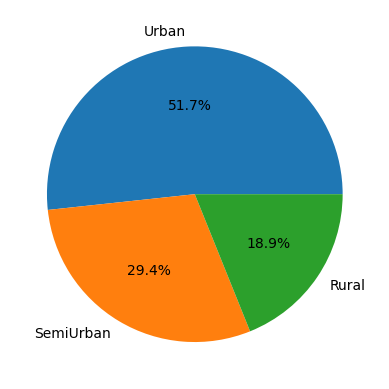

In [51]:
gender_cnt = df['Property_Area'].value_counts()
plt.pie(gender_cnt,labels=['Urban','SemiUrban', 'Rural'], autopct='%1.1f%%')

<Axes: xlabel='Applicant_Income', ylabel='Count'>

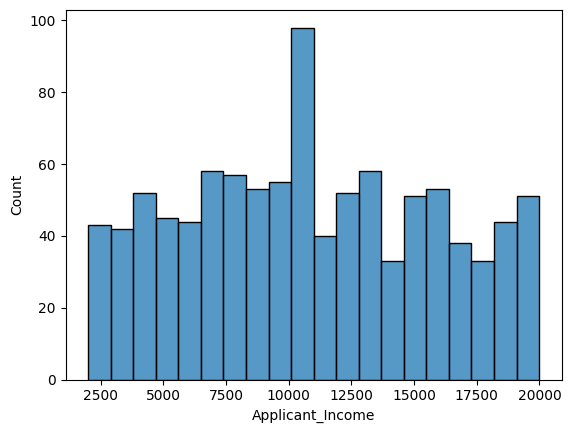

In [52]:
# Analyze Income

sns.histplot(
    data = df,
    x = 'Applicant_Income',
    bins = 20
)

<Axes: xlabel='Age', ylabel='Count'>

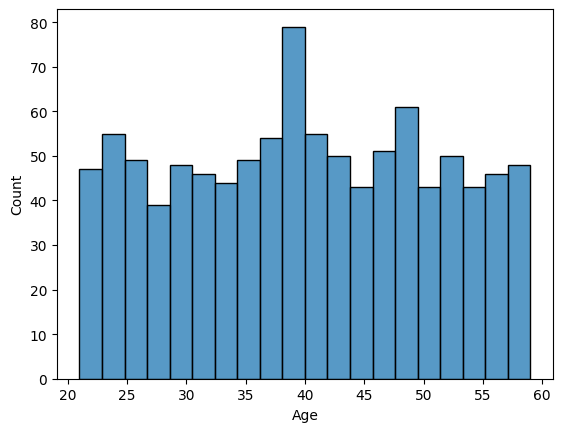

In [53]:
# Analyze Age
sns.histplot(
    data = df,
    x = 'Age',
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

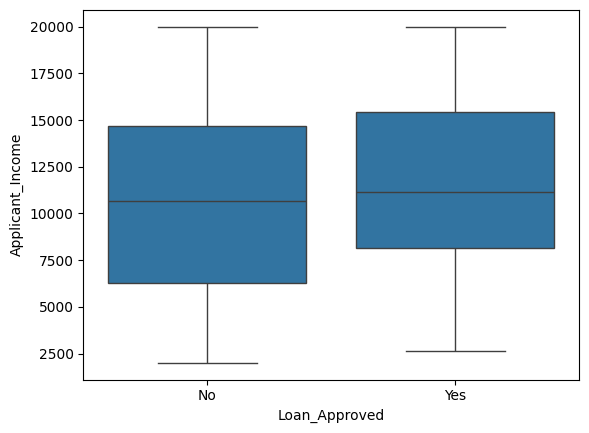

In [54]:
# To check Outliers -> Use box plot

sns.boxplot(
    data = df,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

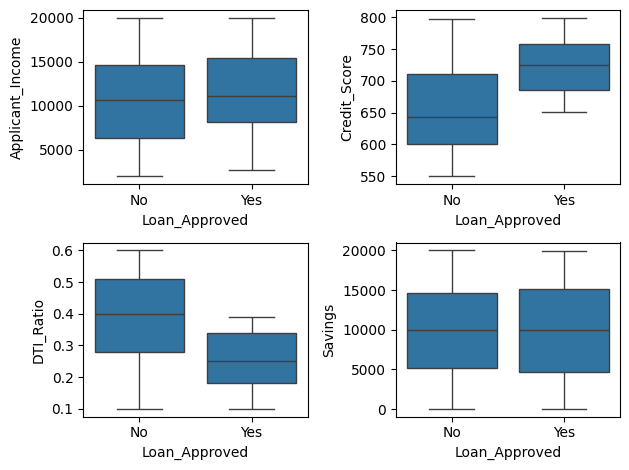

In [55]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=df, x='Loan_Approved', y='Applicant_Income')
sns.boxplot(ax=axes[0,1], data=df, x='Loan_Approved', y='Credit_Score')
sns.boxplot(ax=axes[1,0], data=df, x='Loan_Approved', y='DTI_Ratio')
sns.boxplot(ax=axes[1,1], data=df, x='Loan_Approved', y='Savings')
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

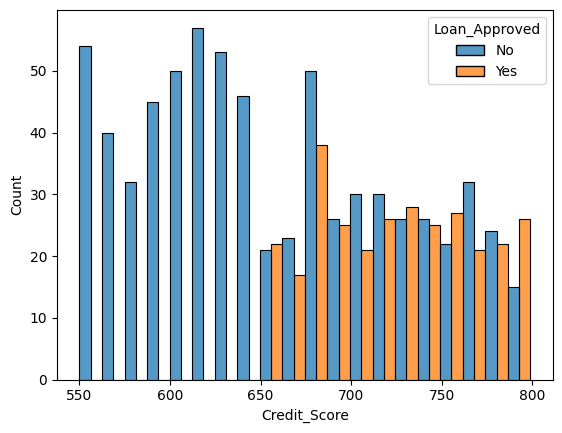

In [56]:
# Credit score VS Loan Approved

sns.histplot(
    data=df,
    x='Credit_Score',
    hue='Loan_Approved',
    bins=20,
    multiple='dodge'
)

In [57]:
df.drop(columns='Applicant_ID',inplace=True)

# Encoding

In [58]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# LabelEncoder is giving the importance to that particular col.. i.e. male=0 & female=1 .. doesn't make sense of any kind of level i.e. female>male
# One hot encoder makes n different cols .. and assigned 0,0,0,...,1 accordingly

le_education = LabelEncoder()
df['Education_Level'] = le_education.fit_transform(df['Education_Level'])

le_target = LabelEncoder()
df['Loan_Approved'] = le_target.fit_transform(df['Loan_Approved'])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [59]:
cols = ['Employment_Status','Marital_Status','Loan_Purpose','Gender','Property_Area','Employer_Category']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols), index=df.index)


df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [60]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [61]:
num_cols = df.select_dtypes(include='number')
corr_matrix = num_cols.corr()   # Makes the correlation Matrix

In [62]:
corr_matrix['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

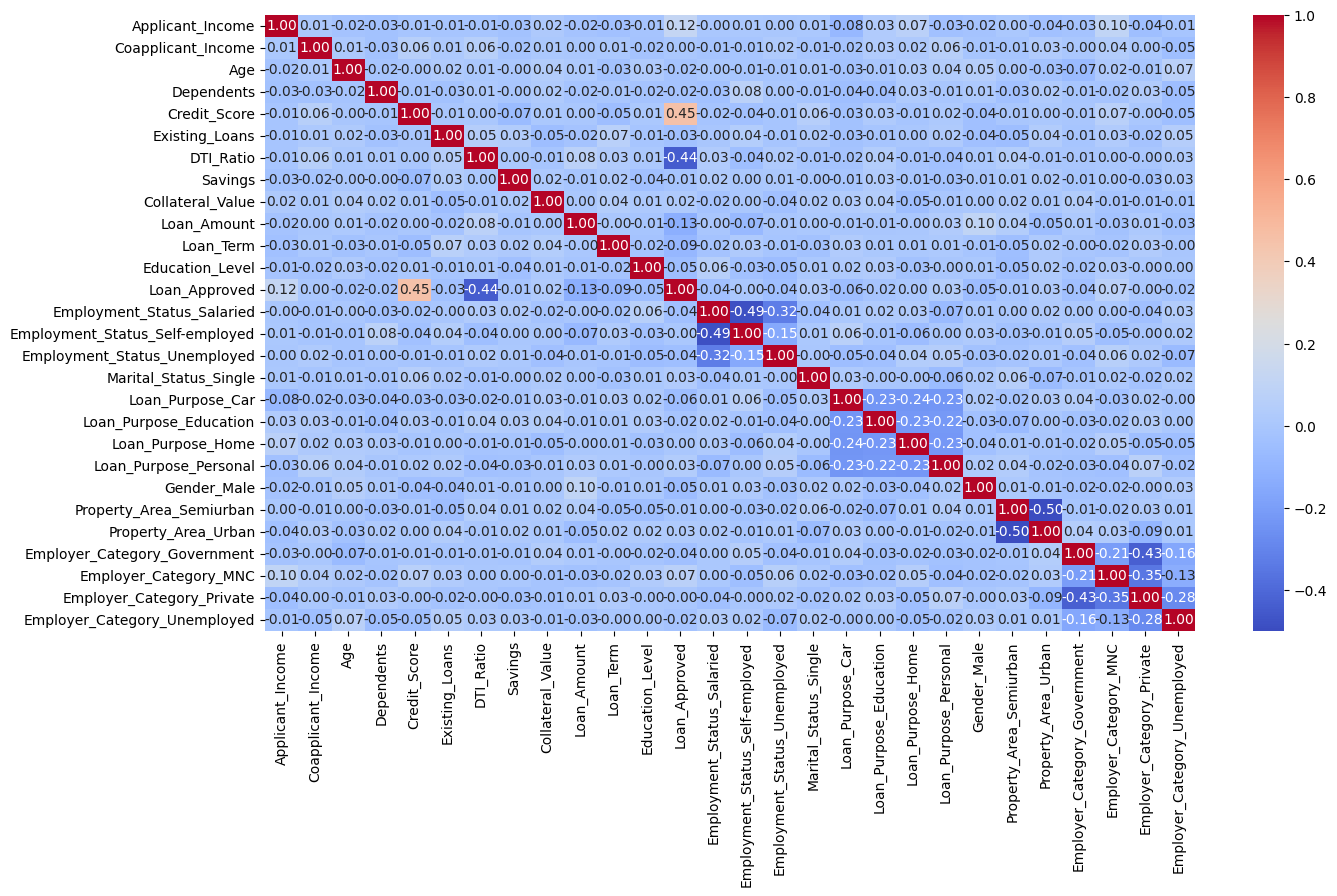

In [63]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

# Split the data

In [64]:
X = df.drop(columns=['Loan_Approved','Coapplicant_Income','Existing_Loans','Collateral_Value'])
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)
X.head()

,Applicant_Income,Age,Dependents,Credit_Score,DTI_Ratio,Savings,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Salaried,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,51.0,0.0,637.0,0.53,19403.0,16619.0,84.0,1,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,46.0,3.0,621.0,0.30,2580.0,38687.0,48.0,0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,25.0,2.0,674.0,0.20,13844.0,27943.0,72.0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,40.0,2.0,579.0,0.31,9553.0,27819.0,60.0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,31.0,2.0,721.0,0.29,9386.0,12741.0,72.0,0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Feature Scaling

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training of Data

In [66]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.87
Recall: 0.7868852459016393
Precision: 0.7868852459016393


In [67]:
# Knn

from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.77
Recall: 0.5901639344262295
Precision: 0.631578947368421


In [68]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.865
Recall: 0.7377049180327869
Precision: 0.8035714285714286


In [69]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.905
Recall: 0.8360655737704918
Precision: 0.85


In [70]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier
d_t = DecisionTreeClassifier(random_state=42)
d_t.fit(X_train_scaled,y_train)
y_pred = d_t.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.885
Recall: 0.819672131147541
Precision: 0.8064516129032258


In [71]:
# XGBoost
from xgboost import XGBClassifier
xg_model = XGBClassifier(random_state=42)
xg_model.fit(X_train_scaled,y_train)
y_pred = xg_model.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.915
Recall: 0.9016393442622951
Precision: 0.8333333333333334


In [72]:
# The best model from above on the basis of precision is Random Forest

# Feature Engineering

In [73]:
df['DTI_Ratio_sq'] = df['DTI_Ratio']**2
df['Credit_Score_sq'] = df['Credit_Score']**2

X = df.drop(columns = ['Loan_Approved','Credit_Score','DTI_Ratio'])
y = df['Loan_Approved'] 

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.model_selection import GridSearchCV


In [74]:
# Naive Bayes

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Smoothing parameter
}
model = GaussianNB()
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross validation
    scoring='precision',       # or 'roc_auc'
)   

grid.fit(X_train_scaled,y_train)
y_pred = grid.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")

Accuracy: 0.865
Recall: 0.7704918032786885
Precision: 0.7833333333333333


In [75]:
# Logistic Regression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularization strength
    'penalty': ['l2'],                     # l1 requires solver change
    'solver': ['lbfgs'],                   # compatible solver
    'class_weight': [None, 'balanced']
}
model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross validation
    scoring='precision',       
)

grid.fit(X_train_scaled,y_train)
y_pred = grid.predict(X_test_scaled)

# Evaluation

from sklearn.metrics import precision_score, recall_score, accuracy_score
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Recall: {recall_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred)}")


Accuracy: 0.835
Recall: 0.5245901639344263
Precision: 0.8888888888888888


In [76]:
# Now logistic Regression is final model with the best precision score of 89%

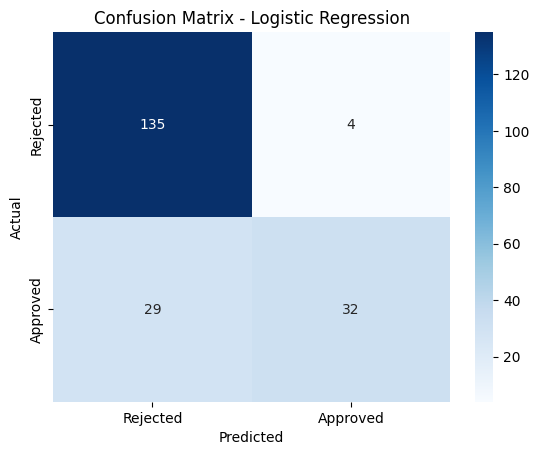

              precision    recall  f1-score   support

           0       0.82      0.97      0.89       139
           1       0.89      0.52      0.66        61

    accuracy                           0.83       200
   macro avg       0.86      0.75      0.78       200
weighted avg       0.84      0.83      0.82       200

[0.13289868 0.11261558 0.04153416 0.44893438 0.04941158 0.63735013
 0.16733645 0.26506913 0.09464218 0.3063922  0.18482727 0.15778082
 0.58465192 0.19042171 0.65482565 0.31016312 0.25953589 0.05048895
 0.12768308 0.52293328 0.44466461 0.3462966  0.42629256 0.40603068
 0.23134277 0.23269267 0.30441573 0.18674066 0.19570854 0.06758398
 0.44019153 0.24281648 0.42463927 0.18035025 0.22544088 0.11172409
 0.23054522 0.43842046 0.12396181 0.08840643 0.51306631 0.16289561
 0.36073429 0.42613759 0.52599896 0.26212106 0.44508905 0.31501103
 0.13762309 0.21432038 0.10421612 0.43434672 0.50144159 0.08191658
 0.47102349 0.35929793 0.30265432 0.61813081 0.18193469 0.18286093
 0.

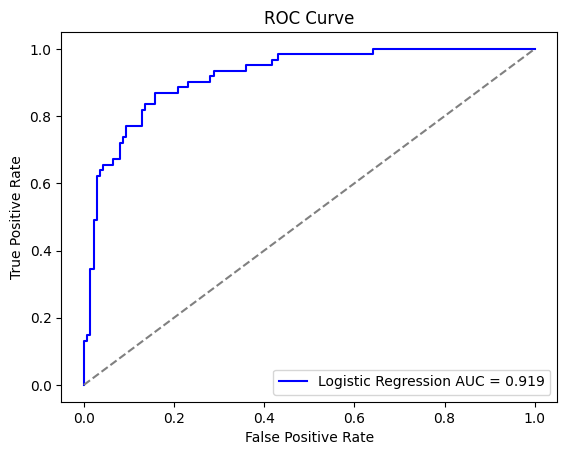

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, y_pred))

# ROC-AUC
# get predicted probabilities for the positive class
try:
    y_prob = grid.predict_proba(X_test_scaled)[:, 1]
    # print(y_prob)
except NameError:
    # fallback to plain model if grid is not defined // Random Forest
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.3f}", color='blue')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<class 'sklearn.linear_model._logistic.LogisticRegression'>


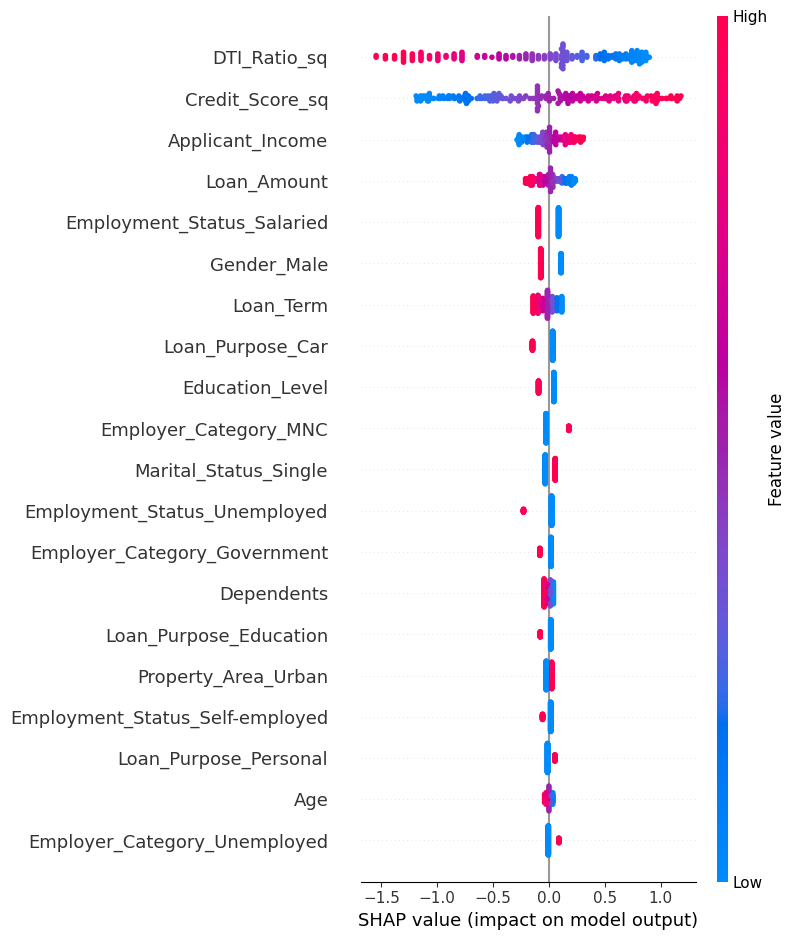

In [78]:
import shap

# Extract the actual Logistic Regression from GridSearchCV
lr_model = grid.best_estimator_

# Verify it's actually a Logistic Regression
print(type(lr_model))  # Should print: <class 'sklearn.linear_model._logistic.LogisticRegression'>

# Now use LinearExplainer
explainer = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Overall feature importance
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

In [79]:
import pickle
import os

# Exact path where you want to save
SAVE_PATH = r'C:\Sem6_Proj\Ml_Model'

# Create folder if it doesn't exist
os.makedirs(SAVE_PATH, exist_ok=True)

# Save all files
pickle.dump(grid.best_estimator_, open(os.path.join(SAVE_PATH, 'model.pkl'), 'wb'))
pickle.dump(scaler,               open(os.path.join(SAVE_PATH, 'scaler.pkl'), 'wb'))
pickle.dump(ohe,                  open(os.path.join(SAVE_PATH, 'ohe_encoder.pkl'), 'wb'))
pickle.dump(le_target,                   open(os.path.join(SAVE_PATH, 'label_encoder.pkl'), 'wb'))
pickle.dump(X.columns.tolist(),   open(os.path.join(SAVE_PATH, 'feature_names.pkl'), 'wb'))

print("✅ Files saved successfully!")
print("📁 Location:", SAVE_PATH)
print("📄 Files:", os.listdir(SAVE_PATH))

✅ Files saved successfully!
📁 Location: C:\Sem6_Proj\Ml_Model
📄 Files: ['feature_names.pkl', 'label_encoder.pkl', 'model.pkl', 'ohe_encoder.pkl', 'scaler.pkl']


In [80]:
print("LabelEncoder classes:", le_target.classes_)

LabelEncoder classes: ['No' 'Yes']
